# Site Classification Results

## Objective
Evaluate how well a classifier can identify the source hospital from EEG features,
and whether harmonization methods reduce this site-specific signal.

## Experiment Design
- **CV:** 5-fold stratified cross-validation
- **Models:** CatBoost, Logistic Regression
- **Harmonization methods:** raw, sitewise, combat, neurocombat, covbat
- **Features:** Manual (no scaler, no PCA)
- **Metric:** MCC (overall and per-hospital)

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.visualization.style import apply_style, legend_kwargs
apply_style()
import re

RESULTS_FILE = 'results/tables/02_site_effect/site_clf_results.csv'
FIGURES_DIR  = 'results/figures/02_site_effect'
TABLES_DIR   = 'results/tables/02_site_effect'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

METHODS    = ['raw', 'sitewise', 'combat', 'neurocombat', 'covbat']
MODELS     = ['catboost', 'logreg']
from src.visualization.style import METHOD_COLORS as COLOR_MAP
MODEL_MARKERS = {'catboost': 'o', 'logreg': 's'}

from src.visualization.style import natural_sort_key



In [3]:
df = pd.read_csv(RESULTS_FILE)
print(f"Shape: {df.shape}")
print(f"Models: {df['model'].unique()}")
print(f"Methods: {df['method'].unique()}")
print(f"Folds: {df['fold'].unique()}")
df.head()

Shape: (50, 34)
Models: ['catboost' 'logreg']
Methods: ['raw' 'sitewise' 'combat' 'neurocombat' 'covbat']
Folds: [1 2 3 4 5]


,mcc_overall,mcc_H25,mcc_H1,mcc_H27,mcc_H14,mcc_H29,mcc_H4,mcc_H7,mcc_H3,mcc_H12,...,mcc_H15,mcc_H23,mcc_H26,mcc_H10,mcc_H19,mcc_H11,mcc_H24,model,method,fold
0,0.854166,0.928906,0.880085,0.826657,0.468501,0.282349,0.934723,0.872565,0.911563,0.777775,...,0.839172,0.791603,0.113406,0.826450,0.925789,0.815232,0.807192,catboost,raw,1
1,0.856689,0.941518,0.886432,0.937654,0.457516,0.437830,0.935405,0.859307,0.904168,0.814416,...,0.820316,0.788216,0.062507,0.834646,0.898796,0.796829,0.732865,catboost,raw,2
2,0.847241,0.911250,0.872597,0.928807,0.559769,0.390952,0.933911,0.846196,0.896346,0.796724,...,0.800605,0.617835,0.193883,0.841832,0.913589,0.792465,0.766794,catboost,raw,3
3,0.848680,0.964181,0.877223,0.879892,0.520246,0.414909,0.928776,0.871776,0.907152,0.774753,...,0.799508,0.775044,-0.001169,0.812875,0.876873,0.788703,0.771496,catboost,raw,4
4,0.855732,0.934588,0.883946,0.882178,0.487016,0.282349,0.929705,0.853800,0.910383,0.815677,...,0.792615,0.836622,0.192236,0.857454,0.914171,0.798786,0.742030,catboost,raw,5


## Summary Table — Mean MCC by Method and Model

In [4]:
summary = (
    df.groupby(['model', 'method'])['mcc_overall']
    .agg(['mean', 'std'])
    .round(4)
    .rename(columns={'mean': 'MCC_mean', 'std': 'MCC_std'})
)
summary = summary.reindex(pd.MultiIndex.from_product([MODELS, METHODS], names=['model', 'method']), fill_value=np.nan)
print(summary.to_string())

# Save
summary.to_csv(f'{TABLES_DIR}/site_clf_summary.csv')
print(f"\nSaved to {TABLES_DIR}/site_clf_summary.csv")

                      MCC_mean  MCC_std
model    method                        
catboost raw            0.8525   0.0043
         sitewise       0.9753   0.0024
         combat         0.9733   0.0030
         neurocombat    0.9728   0.0038
         covbat         0.9296   0.0038
logreg   raw            0.8567   0.0035
         sitewise       0.0008   0.0010
         combat         0.0141   0.0065
         neurocombat    0.0150   0.0063
         covbat         0.1602   0.0146

Saved to results/tables/02_site_effect/site_clf_summary.csv


## Heatmap — Mean MCC (Model x Method)

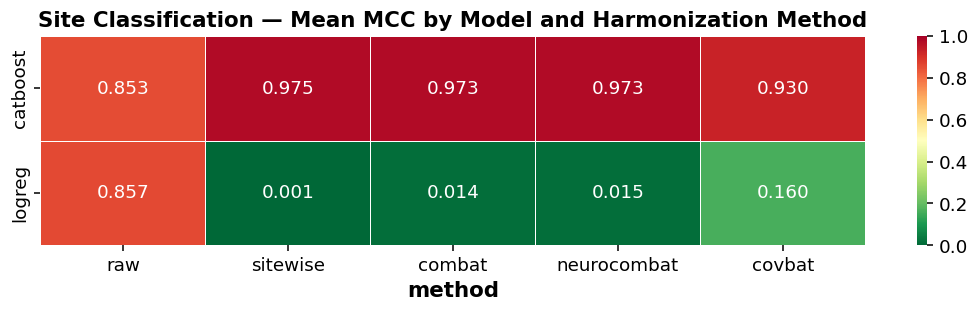

In [5]:
pivot = summary['MCC_mean'].unstack(level='method').reindex(columns=METHODS)

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Site Classification — Mean MCC by Model and Harmonization Method', fontsize=14)
ax.set_ylabel('')
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/site_mcc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Bar Chart — Mean MCC per Method (grouped by model)

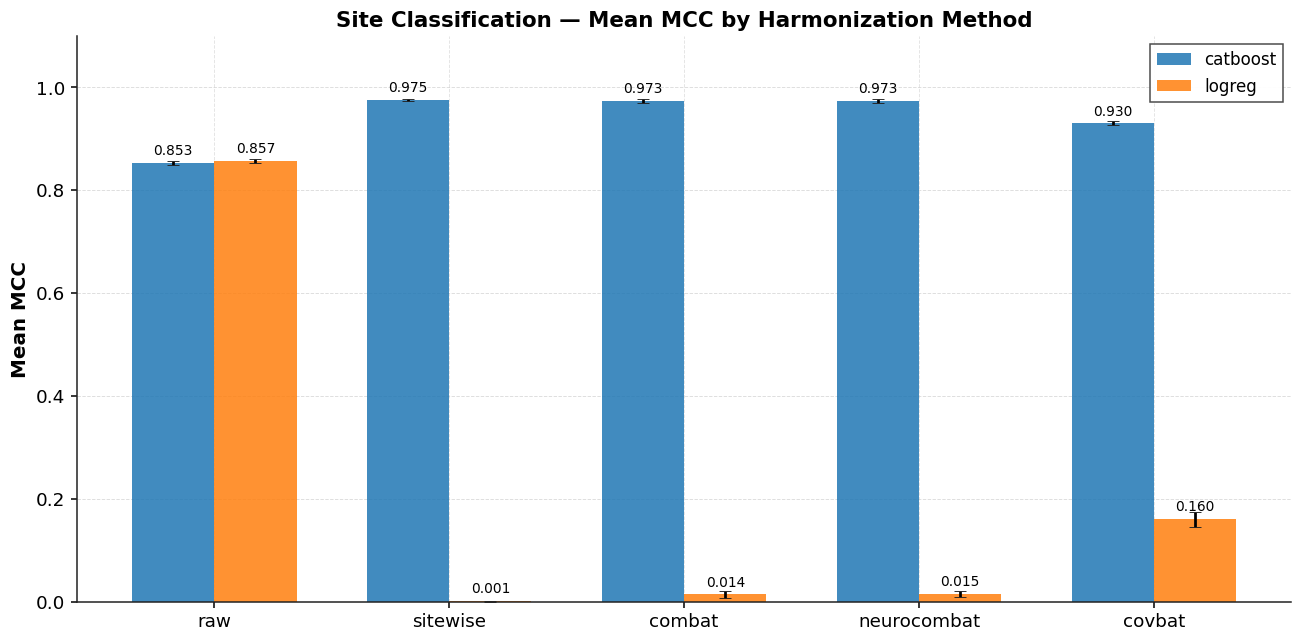

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(METHODS))
width = 0.35

for i, model in enumerate(MODELS):
    model_data = df[df['model'] == model].groupby('method')['mcc_overall'].agg(['mean', 'std'])
    model_data = model_data.reindex(METHODS)
    bars = ax.bar(x + i * width, model_data['mean'], width,
                  yerr=model_data['std'], capsize=4,
                  label=model, alpha=0.85)
    # Value labels
    for bar, val in zip(bars, model_data['mean']):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Mean MCC', fontsize=13)
ax.set_title('Site Classification — Mean MCC by Harmonization Method', fontsize=14)
ax.set_xticks(x + width/2)
ax.set_xticklabels(METHODS, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/site_mcc_bar_by_method.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Hospital MCC — CatBoost

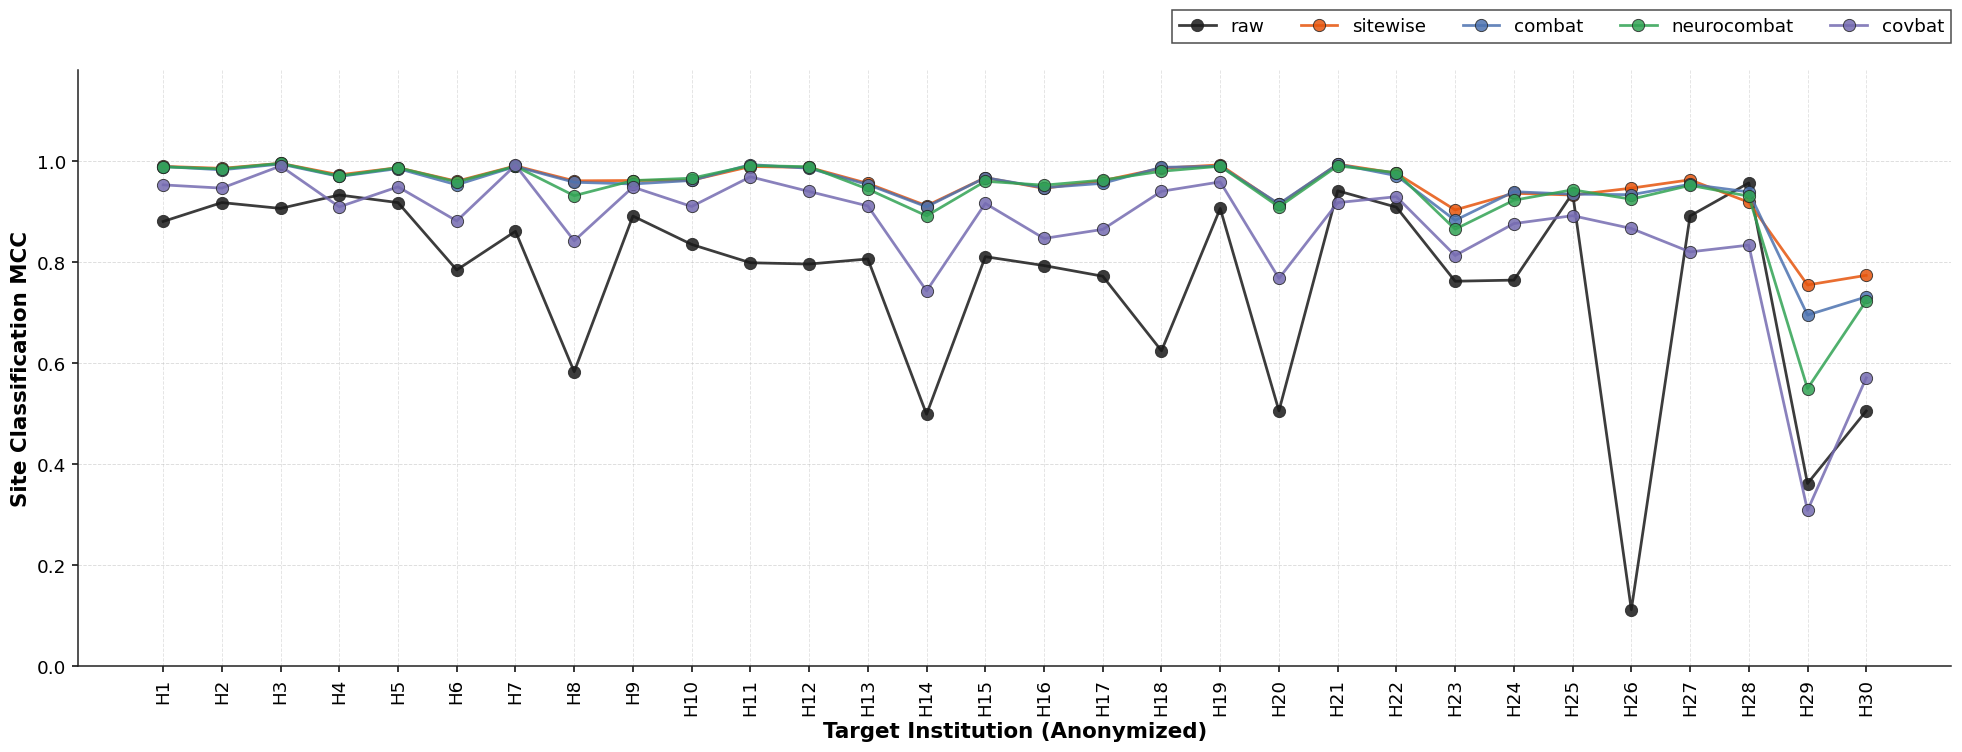

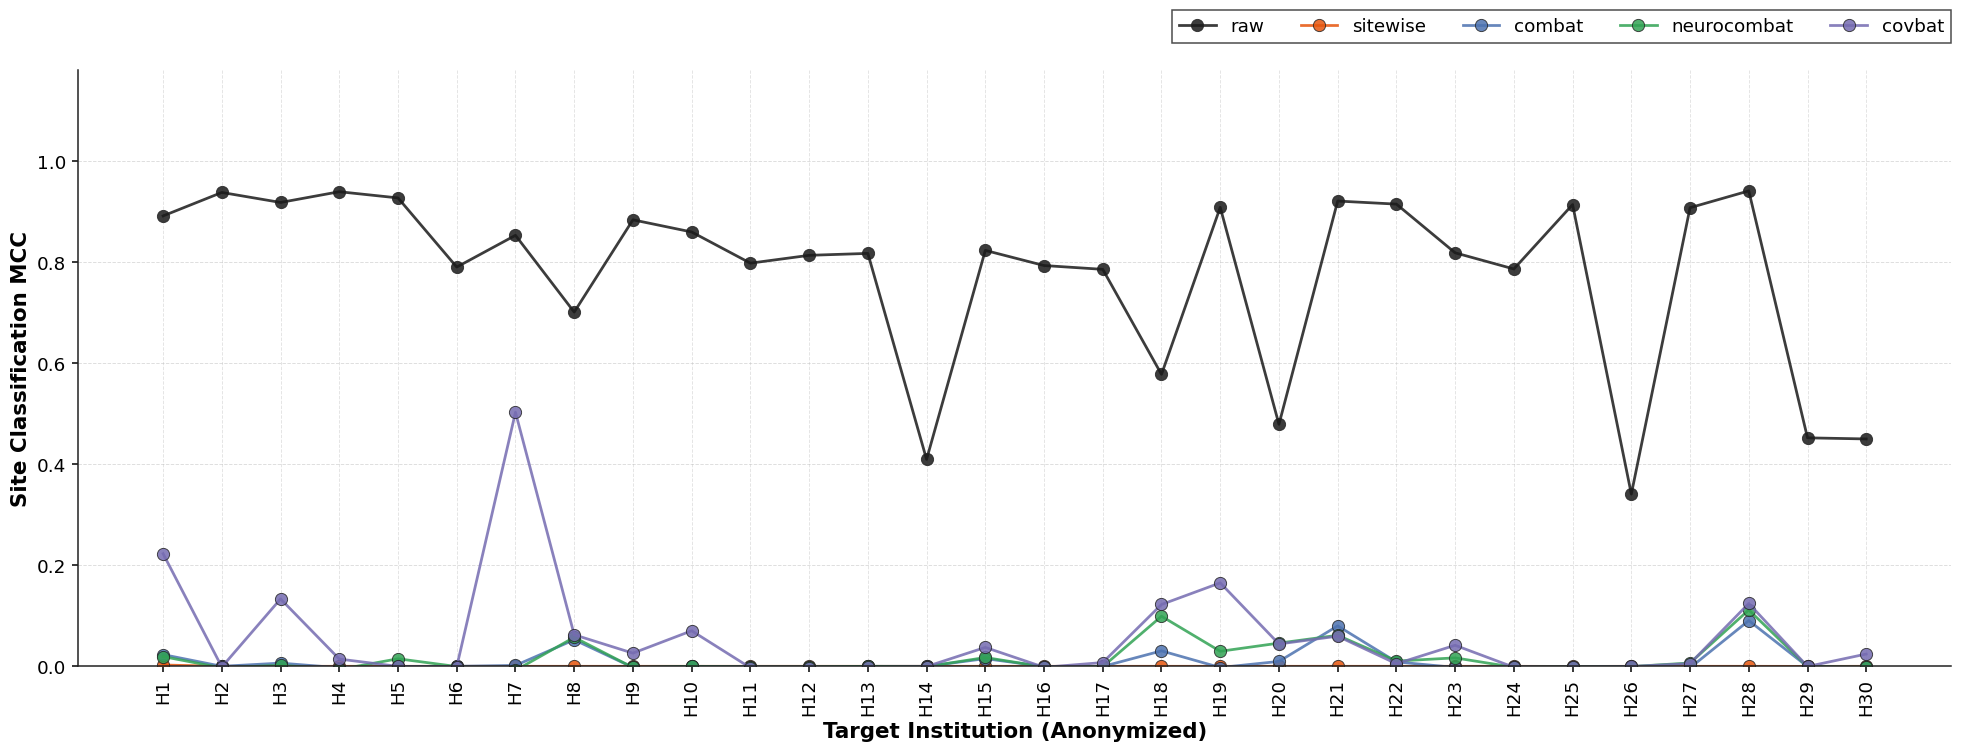

In [7]:
# Extract hospital MCC columns, naturally sorted
hospital_cols = sorted(
    [c for c in df.columns if c.startswith('mcc_H')],
    key=lambda c: natural_sort_key(c.replace('mcc_', ''))
)
hospitals_sorted = [c.replace('mcc_', '') for c in hospital_cols]

for model in MODELS:
    model_df = df[df['model'] == model]
    if model_df.empty:
        print(f"No results for {model}, skipping.")
        continue

    # Mean per-hospital MCC across folds
    mean_per_hospital = model_df.groupby('method')[hospital_cols].mean()

    fig, ax = plt.subplots(figsize=(18, 7))
    for method in METHODS:
        if method not in mean_per_hospital.index:
            continue
        values = [mean_per_hospital.loc[method, f'mcc_{h}'] for h in hospitals_sorted]
        ax.plot(hospitals_sorted, values, marker='o', linestyle='-',
                color=COLOR_MAP[method], label=method, alpha=0.85)

    ax.set_ylabel('Site Classification MCC')
    ax.set_xlabel('Target Institution (Anonymized)')
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0, 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(**legend_kwargs(ncol=len(METHODS)))
    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/site_mcc_per_hospital_{model}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Fold Variance — MCC Distribution per Method

/tmp/ipykernel_2083/1734891277.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='model_method', y='mcc_overall', order=order, ax=ax,
/tmp/ipykernel_2083/1734891277.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


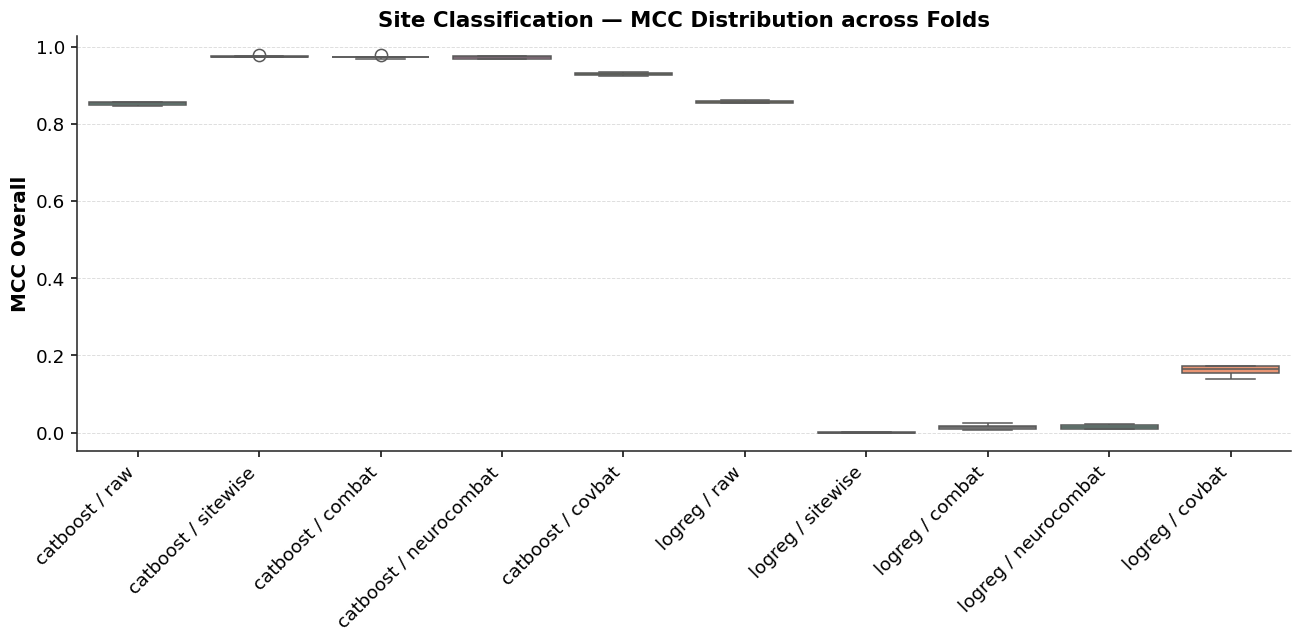

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = df[df['model'].isin(MODELS)].copy()
plot_data['model_method'] = plot_data['model'] + ' / ' + plot_data['method']

order = [f'{m} / {method}' for m in MODELS for method in METHODS
         if not plot_data[(plot_data['model'] == m) & (plot_data['method'] == method)].empty]

sns.boxplot(data=plot_data, x='model_method', y='mcc_overall', order=order, ax=ax,
            palette='Set2')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('MCC Overall', fontsize=13)
ax.set_xlabel('')
ax.set_title('Site Classification — MCC Distribution across Folds', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/site_mcc_fold_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()